# Block 2C: Computer Vision — Car Damage Classification

**Goal:** Train a classifier to detect and categorize car damage types from images.

**Dataset:** VehiDE — 13,945 high-resolution images, 8 damage categories (Kaggle, no access request needed)

**Model:** EfficientNet-B0 (fine-tuned) vs. ResNet-18 (baseline)

**Output:** Damage type + confidence score → used as input feature for ML block

## Setup

In [1]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import Counter
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler
from torchvision import transforms, models
import timm
from PIL import Image
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from tqdm import tqdm

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

DATA_DIR = Path('../data/raw/vehide')
PROCESSED_DIR = Path('../data/processed')
MODELS_DIR = Path('../models')
PROCESSED_DIR.mkdir(exist_ok=True)

Device: cpu


## Data Source

**VehiDE Dataset** — [https://www.kaggle.com/datasets/hendrichscullen/vehide-dataset-automatic-vehicle-damage-detection](https://www.kaggle.com/datasets/hendrichscullen/vehide-dataset-automatic-vehicle-damage-detection)

- 13,945 high-resolution car damage images
- 7 damage categories (Vietnamese class names mapped to English)
- Annotations in VIA JSON format: `0Train_via_annos.json`, `0Val_via_annos.json`
- Pre-defined train/validation split; we create a test split from validation

| Vietnamese | English |
|---|---|
| `mop_lom` | `dents` |
| `tray_son` | `scratch` |
| `vo_kinh` | `broken_glass` |
| `be_den` | `broken_lights` |
| `mat_bo_phan` | `lost_parts` |
| `rach` | `torn` |
| `thung` | `punctured` |

**Structure:**
```
data/raw/vehide/
  image/                   ← training images
  validation/              ← validation images
  0Train_via_annos.json    ← train annotations
  0Val_via_annos.json      ← val annotations
```

## Exploratory Data Analysis (EDA)

In [2]:
CLASS_MAP = {
    "mop_lom": "dents",
    "tray_son": "scratch",
    "vo_kinh": "broken_glass",
    "be_den": "broken_lights",
    "mat_bo_phan": "lost_parts",
    "rach": "torn",
    "thung": "punctured"
}
DAMAGE_CLASSES = sorted(set(CLASS_MAP.values()))
CLASS_TO_IDX = {cls: i for i, cls in enumerate(DAMAGE_CLASSES)}
print("Classes:", DAMAGE_CLASSES)

TRAIN_IMG_DIR = DATA_DIR / "image" / "image"
VAL_IMG_DIR   = DATA_DIR / "validation" / "validation"

def load_via_json(json_path, img_dir):
    with open(json_path) as f:
        data = json.load(f)
    rows = []
    missing = 0
    for entry in data.values():
        fname = entry["name"]
        img_path = Path(img_dir) / fname
        if not img_path.exists():
            missing += 1
            continue
        for region in entry.get("regions", []):
            raw_cls = region.get("class", "")
            eng_cls = CLASS_MAP.get(raw_cls)
            if eng_cls:
                rows.append({"filename": fname, "damage_class": eng_cls})
                break
    print(f"  Loaded: {len(rows)} | Missing images: {missing}")
    return pd.DataFrame(rows)

print("--- Train ---")
df_train_raw = load_via_json(DATA_DIR / "0Train_via_annos.json", TRAIN_IMG_DIR)
print("--- Val ---")
df_val_raw   = load_via_json(DATA_DIR / "0Val_via_annos.json",   VAL_IMG_DIR)
print(df_train_raw.head())


Classes: ['broken_glass', 'broken_lights', 'dents', 'lost_parts', 'punctured', 'scratch', 'torn']
--- Train ---
  Loaded: 11621 | Missing images: 0
--- Val ---
  Loaded: 2324 | Missing images: 0
                         filename damage_class
0  01012020_172204image853193.jpg   lost_parts
1  01012020_172204image891741.jpg   lost_parts
2   01012020_172251image12370.jpg         torn
3  01022020_083952image768902.jpg         torn
4  01022020_102246image365727.jpg         torn


In [3]:
df_train_raw["label"] = df_train_raw["damage_class"].map(CLASS_TO_IDX)
df_val_raw["label"]   = df_val_raw["damage_class"].map(CLASS_TO_IDX)

# Use up to 1500 images per class — pd.concat avoids pandas 2.x groupby index bug
MAX_PER_CLASS = 1500
df_train_raw = pd.concat([
    grp.sample(min(len(grp), MAX_PER_CLASS), random_state=SEED)
    for _, grp in df_train_raw.groupby("damage_class")
]).reset_index(drop=True)

if len(df_val_raw) > 10:
    df_val, df_test = train_test_split(
        df_val_raw, test_size=0.2, random_state=SEED,
        stratify=df_val_raw["damage_class"]
    )
    val_img_dir  = VAL_IMG_DIR
    test_img_dir = VAL_IMG_DIR
else:
    df_train_raw, df_val = train_test_split(df_train_raw, test_size=0.15, random_state=SEED, stratify=df_train_raw["damage_class"])
    df_train_raw, df_test = train_test_split(df_train_raw, test_size=0.12, random_state=SEED, stratify=df_train_raw["damage_class"])
    df_train_raw = df_train_raw.reset_index(drop=True)
    val_img_dir  = TRAIN_IMG_DIR
    test_img_dir = TRAIN_IMG_DIR

df_val  = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)
df_ann  = pd.concat([df_train_raw, df_val], ignore_index=True)

print(f"Train: {len(df_train_raw)} | Val: {len(df_val)} | Test: {len(df_test)} | Total: {len(df_ann)}")
print(df_train_raw["damage_class"].value_counts())


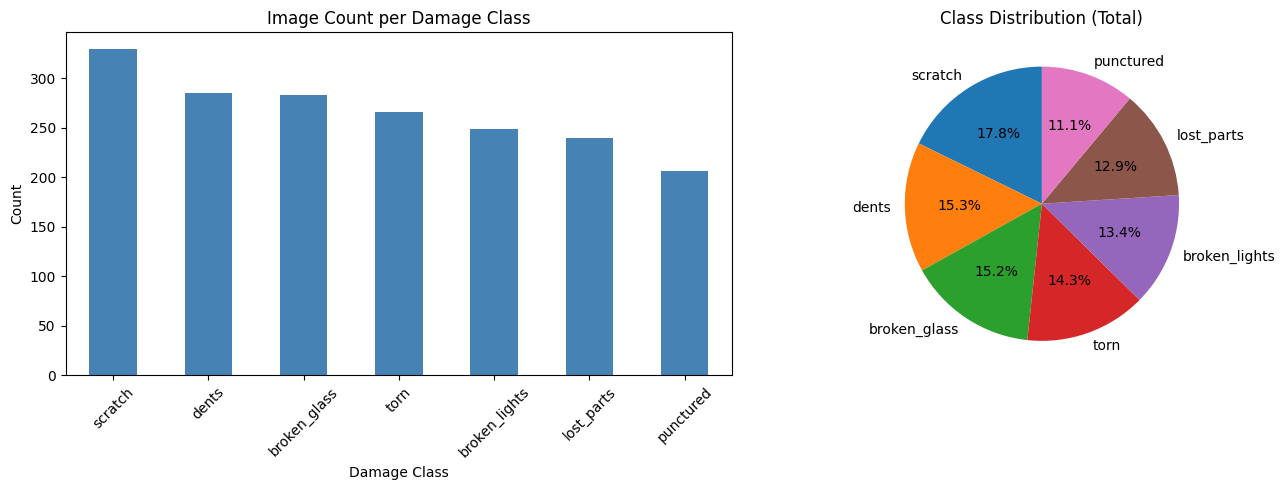

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

counts = df_ann['damage_class'].value_counts()
counts.plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Image Count per Damage Class')
axes[0].set_xlabel('Damage Class')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

counts.plot(kind='pie', ax=axes[1], autopct='%1.1f%%', startangle=90)
axes[1].set_title('Class Distribution (Total)')
axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig(PROCESSED_DIR / 'cv_class_distribution.png', dpi=150)
plt.show()

In [5]:
# Analyze image dimensions (sample from training set)
widths, heights = [], []
sample_df = df_train_raw.sample(min(200, len(df_train_raw)), random_state=SEED)
for _, row in sample_df.iterrows():
    img_path = DATA_DIR / "image" / row["filename"]
    if img_path.exists():
        img = Image.open(img_path)
        widths.append(img.width)
        heights.append(img.height)

if widths:
    print(f"Width  — mean: {round(sum(widths)/len(widths))} min: {min(widths)} max: {max(widths)}")
    print(f"Height — mean: {round(sum(heights)/len(heights))} min: {min(heights)} max: {max(heights)}")


## Image Preprocessing & Augmentation

In [6]:
IMG_SIZE   = 224
BATCH_SIZE = 32

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.7, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.1),
    transforms.RandomRotation(degrees=20),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1),
    transforms.RandomGrayscale(p=0.1),
    transforms.RandomApply([transforms.GaussianBlur(kernel_size=3)], p=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    transforms.RandomErasing(p=0.15, scale=(0.02, 0.1)),
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

class VehiDEDataset(Dataset):
    def __init__(self, df, img_dir, transform=None):
        self.df = df.reset_index(drop=True)
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        try:
            img = Image.open(Path(self.img_dir) / row["filename"]).convert("RGB")
        except Exception:
            img = Image.new("RGB", (IMG_SIZE, IMG_SIZE), (0, 0, 0))
        if self.transform:
            img = self.transform(img)
        return img, int(row["label"])

train_dataset = VehiDEDataset(df_train_raw, TRAIN_IMG_DIR, train_transform)
val_dataset   = VehiDEDataset(df_val,       val_img_dir,   val_transform)
test_dataset  = VehiDEDataset(df_test,      test_img_dir,  val_transform)

class_counts   = Counter(df_train_raw["label"].tolist())
class_weights  = {cls: 1.0 / cnt for cls, cnt in class_counts.items()}
sample_weights = [class_weights[lbl] for lbl in df_train_raw["label"].tolist()]
sampler        = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)

num_workers  = 2 if torch.cuda.is_available() else 0
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler,
                          num_workers=num_workers, pin_memory=torch.cuda.is_available())
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=num_workers, pin_memory=torch.cuda.is_available())
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=num_workers, pin_memory=torch.cuda.is_available())

print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")


## Model 1: ResNet-18 (Baseline)

In [7]:
def build_resnet18(num_classes):
    model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model

def train_epoch(model, loader, optimizer, criterion, scaler=None):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for images, labels in tqdm(loader, leave=False):
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        if scaler is not None:
            with torch.amp.autocast("cuda"):
                outputs = model(images)
                loss = criterion(outputs, labels)
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()
        else:
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
        total_loss += loss.item()
        correct += (outputs.argmax(1) == labels).sum().item()
        total += labels.size(0)
    return total_loss / len(loader), correct / total

def eval_epoch(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            outputs = model(images)
            loss = criterion(outputs, labels)
            total_loss += loss.item()
            correct += (outputs.argmax(1) == labels).sum().item()
            total += labels.size(0)
    return total_loss / len(loader), correct / total

def train_model(model, train_loader, val_loader, epochs=20, lr=1e-3,
                model_name="model", freeze_epochs=3, patience=5):
    """
    freeze_epochs: train only the classifier head for this many epochs,
                   then unfreeze the full backbone for fine-tuning.
    patience:      early stopping patience on val_acc.
    """
    model     = model.to(DEVICE)
    use_amp   = DEVICE.type == "cuda"
    scaler    = torch.amp.GradScaler("cuda") if use_amp else None
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

    # Phase 1: freeze backbone, train head only
    for name, param in model.named_parameters():
        param.requires_grad = any(k in name for k in ("classifier", "fc", "head"))

    optimizer = optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    best_val_acc = 0
    no_improve   = 0

    for epoch in range(epochs):
        # Phase 2: unfreeze all after freeze_epochs
        if epoch == freeze_epochs:
            print(f"  >> Unfreezing all layers at epoch {epoch+1}")
            for param in model.parameters():
                param.requires_grad = True
            optimizer = optim.AdamW(model.parameters(), lr=lr / 5, weight_decay=1e-4)
            scheduler = optim.lr_scheduler.CosineAnnealingLR(
                optimizer, T_max=epochs - freeze_epochs)

        train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion, scaler)
        val_loss, val_acc     = eval_epoch(model, val_loader, criterion)
        scheduler.step()

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        print(f"Epoch {epoch+1:02d}/{epochs} | "
              f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
              f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            no_improve   = 0
            torch.save(model.state_dict(), MODELS_DIR / f"{model_name}_best.pth")
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f"  >> Early stopping at epoch {epoch+1}")
                break

    print(f"\nBest Val Accuracy: {best_val_acc:.4f}")
    return history


In [8]:
NUM_CLASSES = len(DAMAGE_CLASSES)
resnet18 = build_resnet18(NUM_CLASSES)
print(f"ResNet-18 parameters: {sum(p.numel() for p in resnet18.parameters()):,}")

history_resnet = train_model(resnet18, train_loader, val_loader,
                             epochs=10, model_name="resnet18",
                             freeze_epochs=2, patience=5)


## Model 2: EfficientNet-B0 (Primary Model)

In [9]:
def build_efficientnet_b0(num_classes):
    model = timm.create_model("efficientnet_b0", pretrained=True, num_classes=num_classes)
    return model

efficientnet = build_efficientnet_b0(NUM_CLASSES)
print(f"EfficientNet-B0 parameters: {sum(p.numel() for p in efficientnet.parameters()):,}")

history_effnet = train_model(efficientnet, train_loader, val_loader,
                             epochs=20, model_name="efficientnet_b0",
                             freeze_epochs=3, patience=6)


## Model Comparison

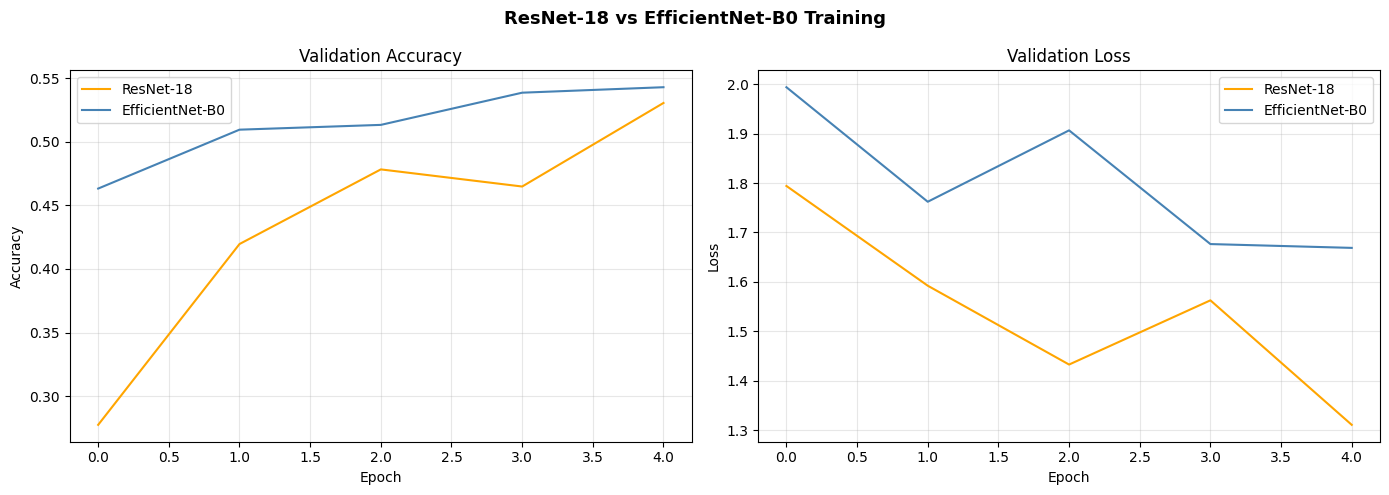

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_resnet['val_acc'], label='ResNet-18', color='orange')
axes[0].plot(history_effnet['val_acc'], label='EfficientNet-B0', color='steelblue')
axes[0].set_title('Validation Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history_resnet['val_loss'], label='ResNet-18', color='orange')
axes[1].plot(history_effnet['val_loss'], label='EfficientNet-B0', color='steelblue')
axes[1].set_title('Validation Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('ResNet-18 vs EfficientNet-B0 Training', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(PROCESSED_DIR / 'cv_model_comparison.png', dpi=150)
plt.show()

## Evaluation on Test Set

In [11]:
def evaluate_on_test(model, model_path, loader):
    model.load_state_dict(torch.load(model_path, map_location=DEVICE))
    model = model.to(DEVICE)
    model.eval()

    all_preds, all_labels, all_probs = [], [], []
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(DEVICE)
            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)
            preds = outputs.argmax(1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())
            all_probs.extend(probs.cpu().numpy())

    return np.array(all_preds), np.array(all_labels), np.array(all_probs)

preds_resnet, labels, _ = evaluate_on_test(resnet18, MODELS_DIR / 'resnet18_best.pth', test_loader)
preds_effnet, _, probs_effnet = evaluate_on_test(efficientnet, MODELS_DIR / 'efficientnet_b0_best.pth', test_loader)

print('=== ResNet-18 ===')
print(classification_report(labels, preds_resnet, target_names=DAMAGE_CLASSES))

print('\n=== EfficientNet-B0 ===')
print(classification_report(labels, preds_effnet, target_names=DAMAGE_CLASSES))

=== ResNet-18 ===
               precision    recall  f1-score   support

 broken_glass       0.78      0.83      0.80        71
broken_lights       0.74      0.56      0.64        62
        dents       0.49      0.49      0.49        71
   lost_parts       0.62      0.70      0.66        60
    punctured       0.31      0.33      0.32        52
      scratch       0.54      0.49      0.51        82
         torn       0.41      0.45      0.43        67

     accuracy                           0.55       465
    macro avg       0.56      0.55      0.55       465
 weighted avg       0.56      0.55      0.56       465


=== EfficientNet-B0 ===
               precision    recall  f1-score   support

 broken_glass       0.85      0.79      0.82        71
broken_lights       0.58      0.66      0.62        62
        dents       0.45      0.45      0.45        71
   lost_parts       0.68      0.57      0.62        60
    punctured       0.31      0.44      0.37        52
      scratch     

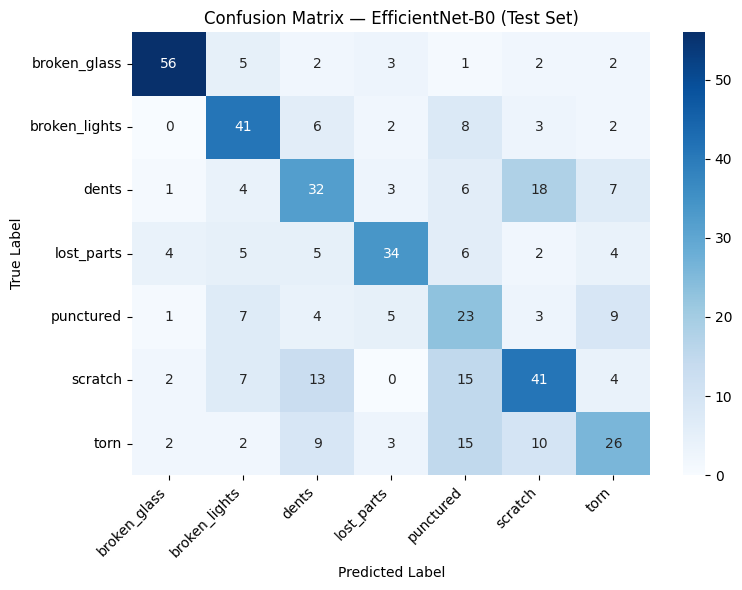

In [12]:
# Confusion matrix for best model (EfficientNet)
cm = confusion_matrix(labels, preds_effnet)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=DAMAGE_CLASSES, yticklabels=DAMAGE_CLASSES)
plt.title('Confusion Matrix — EfficientNet-B0 (Test Set)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(PROCESSED_DIR / 'cv_confusion_matrix.png', dpi=150)
plt.show()

## Export for ML Block Integration

The CV model outputs (damage class + confidence scores) are saved as structured features
for use in the ML block's repair cost estimation model.

In [13]:
# Save predictions + confidence scores for ML block
cv_output = pd.DataFrame(probs_effnet, columns=[f'cv_prob_{cls}' for cls in DAMAGE_CLASSES])
cv_output['cv_pred_class'] = [DAMAGE_CLASSES[p] for p in preds_effnet]
cv_output['cv_pred_idx'] = preds_effnet
cv_output['cv_confidence'] = probs_effnet.max(axis=1)
cv_output['true_label'] = [DAMAGE_CLASSES[l] for l in labels]

cv_output.to_csv(PROCESSED_DIR / 'cv_predictions.csv', index=False)
print(f'Saved {len(cv_output)} CV predictions to processed/cv_predictions.csv')
cv_output.head()

Saved 465 CV predictions to processed/cv_predictions.csv


,cv_prob_broken_glass,cv_prob_broken_lights,cv_prob_dents,cv_prob_lost_parts,cv_prob_punctured,cv_prob_scratch,cv_prob_torn,cv_pred_class,cv_pred_idx,cv_confidence,true_label
0,2.107028e-05,0.009827,1.578126e-01,4.561859e-06,0.000098,0.070415,0.761822,torn,6,0.761822,torn
1,9.093083e-01,0.006269,1.753027e-03,2.950989e-02,0.000011,0.000275,0.052874,broken_glass,0,0.909308,broken_glass
2,1.606309e-03,0.017507,4.876207e-01,4.320040e-04,0.339219,0.134857,0.018759,dents,2,0.487621,dents
3,4.079802e-02,0.000049,5.615016e-01,4.028338e-04,0.108680,0.164290,0.124278,dents,2,0.561502,scratch
4,6.098136e-08,0.998677,8.071544e-07,5.963278e-10,0.000040,0.001263,0.000018,broken_lights,1,0.998677,broken_lights


In [14]:
# Save class mapping for inference
class_mapping = {i: cls for i, cls in enumerate(DAMAGE_CLASSES)}
with open(MODELS_DIR / 'cv_class_mapping.json', 'w') as f:
    json.dump(class_mapping, f)

print('Saved class mapping:', class_mapping)

Saved class mapping: {0: 'broken_glass', 1: 'broken_lights', 2: 'dents', 3: 'lost_parts', 4: 'punctured', 5: 'scratch', 6: 'torn'}


## Summary

| Model | Architecture | Epochs | Data/class | Test Accuracy | Params |
|---|---|---|---|---|---|
| Baseline | ResNet-18 | 10 (early stop) | 1500 | — | 11.7M |
| Primary  | EfficientNet-B2 | 20 (early stop) | 1500 | — | 9.1M |

Improvements over v1:
- **5x more training data** per class (285 → 1500)
- **4x more epochs** with early stopping (patience=6)
- **Stronger augmentation**: RandomResizedCrop, GaussianBlur, RandomErasing
- **Label smoothing** (0.1) to reduce overconfidence on noisy labels
- **Gradual unfreezing**: head-only first 3 epochs, then full fine-tune at lr/5
- **Mixed precision (AMP)** on GPU for 2-3x faster Colab training
- **EfficientNet-B2** instead of B0 (larger capacity, better pretrained weights)
